<a href="https://colab.research.google.com/github/YuranShi/biostat-285-advanced-ml-dl/blob/main/hw3/biostat_285_homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## BIOSTAT 285 Homework 3

In [ ]:
import zipfile
import os
from tqdm import tqdm
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import transforms

### Problem 1: Kernels in clustering

Let $x_{1},...,x_{n}\in\mathbb{R}^{d}$ be data points, and recall the task of k-means clustering with centroids $\theta_{1},...,\theta_{k}$. Let $c(i)\in\{1,...,k\}$ be the cluster assignment of point $x_{i}$.

We will focus on the the k-means assignment step from Lloyd's algorithm:

$$c(i)=\arg \min_{j\in\{1,...,k\}} ||x_{i}-\theta_{j}||^{2}$$

1. Expand the squared distance to show that:
   $$||x_{i}-\theta_{j}||^{2}=x_{i}^{\top}x_{i}-2x_{i}^{\top}\theta_{j}+\theta_{j}^{\top}\theta_{j}$$
   Then identify which one of these three terms can be dropped as it does not affect the $\arg \min$ over $j$; that is, the $\theta_{j}$ that minimizes the expression is the same regardless of whether you include that term.


    **Solution**:
    The squared Euclidean distance can be expanded as:
    
    \begin{align}
    ||x_{i}-\theta_{j}||^{2} &= (x_i - \theta_j)^\top(x_i - \theta_j) \\
    &= x_i^\top x_i - x_i^\top \theta_j - \theta_j^\top x_i + \theta_j^\top \theta_j \\
    &= x_i^\top x_i - 2x_i^\top \theta_j + \theta_j^\top \theta_j
    \end{align}
    
    In the assignment step, we seek the index $j$ that minimizes this expression:
    
    $$c(i) = \arg \min_{j \in \{1, \dots, k\}} \left( x_i^\top x_i - 2x_i^\top \theta_j + \theta_j^\top \theta_j \right)$$

    Since the $\arg \min$ is taken with respect to $j$. The term $x_i^\top x_i$ (the squared norm of the data point) is constant for all possible clusters $j$. Therefore, **the term $x_i^\top x_i$ can be dropped**.

    Therefore, the simplified assignment rule becomes:
    
    $$c(i) = \arg \min_{j} \left( \theta_j^\top \theta_j - 2x_i^\top \theta_j \right)$$


2. You've now re-expressed the assignment step $c(i)=\arg \min_{j\in\{1,...,k\}}||x_{i}-\theta_{j}||^{2}$ instead as dot products, but your answer in the previous part involves $\theta_{j}$'s, and we would like to continue to simplify toward some kernel involving only dot products between data points.

   Fortunately, this should be possible as the centroids are functions of only data points: $\theta_{j}$ were computed as averages:
   $$\theta_{j}=\frac{1}{n_{j}}\sum_{l\in C_{j}}x_{l}$$
   where $C_{j}=\{l:c(l)=j\}$ is the index set of points in cluster $j$ and $n_{j}$ is the size of cluster $j$.

   Show that:
   $$\theta_{j}^{\top}\theta_{j}=\frac{1}{n_{j}^{2}}\sum_{l\in C_{j}}\sum_{m\in C_{j}}x_{l}^{\top}x_{m}$$
   and similarly express your other term in terms of only dot products between the data points.

   **Solution**: To find $\theta_{j}^{\top}\theta_{j}$, we multiply the centroid by its own transpose and expand the product of the two sums using double summation of all pairwise dot product within the cluster.
   
   \begin{align}
   \theta_{j}^{\top}\theta_{j} &= \left( \frac{1}{n_j} \sum_{l \in C_j} x_l \right)^\top \left( \frac{1}{n_j} \sum_{m \in C_j} x_m \right) \\
   &= \frac{1}{n_j^2} \left( \sum_{l \in C_j} x_l^\top \right) \left( \sum_{m \in C_j} x_m \right) \\
   &= \frac{1}{n_j^2} \sum_{l \in C_j} \sum_{m \in C_j} x_l^\top x_m
   \end{align}

   The other term $-2x_i^\top \theta_j$ can be expressed by substituting $\theta_j$:

   \begin{align}
   -2x_i^\top \theta_j &= -2x_i^\top \left( \frac{1}{n_j} \sum_{l \in C_j} x_l \right) \\
   &= -\frac{2}{n_j} \sum_{l \in C_j} x_i^\top x_l
   \end{align}

3. Combine these findings to write an assignment rule $c(i)=\arg \min_{j}g(x_{1},...,x_{n})$ where you should see that your expression $g(\cdot)$ is comprised of dot products between data points.

   This paves the way to derive non-linear extensions under the same idea: if $K(x_{l},x_{m})$ is a valid kernel function, write the assignment rule $c(i)$ that performs a modified version of k-means using this kernel as a similarity.

   **Solution**: Using the results from the previous parts, we substitute the expanded terms back into the assignment rule (ignoring $x_i^\top x_i$ as it doesn't depend on $j$ ):

   $$c(i) = \arg \min_{j} \left( \frac{1}{n_j^2} \sum_{l \in C_j} \sum_{m \in C_j} x_l^\top x_m - \frac{2}{n_j} \sum_{l \in C_j} x_i^\top x_l \right)$$

   Thus, the function $g(x_1, \dots, x_n)$ for a specific cluster $j$ is:
   
   $$g_j(x_1, \dots, x_n) = \frac{1}{n_j^2} \sum_{l \in C_j} \sum_{m \in C_j} x_l^\top x_m - \frac{2}{n_j} \sum_{l \in C_j} x_i^\top x_l$$

   Kernel K-means allows us to perform k-means in a high-dimensional feature space without explicitly calculating the coordinates of the points in feature space. We replace every instance of the dot product $x_a^\top x_b$ with a valid kernel function $K(x_a, x_b)$. And the modified assignment rule $c(i)$ becomes:

   $$c(i) = \arg \min_{j} \left( \frac{1}{n_j^2} \sum_{l \in C_j} \sum_{m \in C_j} K(x_l, x_m) - \frac{2}{n_j} \sum_{l \in C_j} K(x_i, x_l) \right)$$


4. We know that the kernel $K(x_{l},x_{m})$ corresponds to a high-dimensional dot product $\phi(x_{l})^{\top}\phi(x_{m})$ under some mapping. Derive or guess what the objective is in terms of Euclidean distance under the new objective in the last part: that is, what are the counterparts to the $x_{i}$ and how do we (re)-define $\theta_{j}$ from the original rule:

   $$c(i)=\arg \min_{j\in\{1,...,k\}}||x_{i}-\theta_{j}||^{2}$$

   so that we can write the kernel version as the squared norm of a difference between two terms?

   **Solution:** We know that the kernel $K(x_l, x_m)$ represents the dot product $\phi(x_l)^\top \phi(x_m)$ in a high-dimensional space. Therefore, the counterparts to the original data points $x_i$ are their mapped versions in the feature space:
   
   $$\Phi_i = \phi(x_i)$$
   
   In the original k-means algorithm, the centroid $\theta_j$ is the mean of the points in cluster $j$. Following that same logic, we define the counterpart centroid $\tilde{\theta}_j$ in the feature space as:

   $$\tilde{\theta}_j = \frac{1}{n_j} \sum_{l \in C_j} \phi(x_l)$$

   To write the kernel version as the squared norm of a difference between two terms, we look at the distance in the feature space:

   $$\|\phi(x_i) - \tilde{\theta}_j\|^2 = \phi(x_i)^\top \phi(x_i) - 2\phi(x_i)^\top \tilde{\theta}_j + \tilde{\theta}_j^\top \tilde{\theta}_j$$

   If we substitute the definition of $\tilde{\theta}_j$ into this expansion:
   $$\phi(x_i)^\top \phi(x_i) = K(x_i, x_i)$$

   $$2\phi(x_i)^\top \tilde{\theta}_j = \frac{2}{n_j} \sum_{l \in C_j} K(x_i, x_l)$$

   $$\tilde{\theta}_j^\top \tilde{\theta}_j = \frac{1}{n_j^2} \sum_{l \in C_j} \sum_{m \in C_j} K(x_l, x_m)$$

   By minimizing the squared Euclidean distance in this high-dimensional space, we find that kernel assignment rule is k-means performed on the mapped points $\phi(x_i)$.

### Problem 2: Autoencoder (AE) and Variational Autoencoder (VAE)

Save the CelebA images dataset comprising 50,000 celebrity images in your desired directory. Use the following code to store a subset of 10,000 images. We first sort the file names to ensure the same subset gets selected and reshape each image to $64\times64$ pixels also converting it to Grayscale.

```python
import numpy as np
import os
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, Subset
from torchvision import transforms
import tensorflow as tf

final_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(),
    transforms.ToTensor(),
])

class OptimizedFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Only grab images
        self.image_files = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, 0

# Provide the path to the directory where the images are saved here
data_path = "path"
full_dataset = OptimizedFaceDataset(root_dir=data_path, transform=final_transform)
ten_k_dataset = Subset(full_dataset, range(10000))

X_list = []
for i in tqdm(range(len(ten_k_dataset)), desc="Flattening for PCA/Dense VAE"):
    img, _ = ten_k_dataset[i]
    X_list.append(img.numpy().flatten())
x = np.array(X_list)
```

1. First apply Principal Component Analysis (PCA) to the data preserving 95% of the variance.
Reconstruct the first 5 images and compare to the original images.


In [ ]:
# First upload the celebA.zip into Colab files
# Extract uploaded zip file
zip_path = 'CelebA.zip'
extract_path = '/content/extracted_data'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")

Extraction complete.


In [ ]:
#---------------------------------------
# Provided Code to Parse CelebA Dataset
#---------------------------------------
final_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(),
    transforms.ToTensor(),
])

class OptimizedFaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Only grab images
        self.image_files = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, 0


In [ ]:
# Plotting Function (Problem 2)
def plot_results(image_sets, titles, num_images=5):
    """
    Plots a grid of images for comparison.

    Args:
        image_sets: List of numpy arrays (each set containing images to plot).
        titles: List of strings for row labels (e.g., ["Original", "PCA", "AE"]).
        num_images: Number of images to show per row (default 5).
    """
    num_rows = len(image_sets)

    dynamic_height = num_rows * 3
    fig, axes = plt.subplots(num_rows, num_images, figsize=(15, dynamic_height))

    # Ensure axes is a 2D array even for a single row
    if num_rows == 1:
        axes = axes.reshape(1, -1)

    for row in range(num_rows):
        for col in range(num_images):
            ax = axes[row, col]

            # Handle potential indexing issues if a set has fewer than num_images
            if col < len(image_sets[row]):
                img = image_sets[row][col].reshape(64, 64)
                ax.imshow(img, cmap='gray')

            ax.axis("off")

            # Add Row Label
            if col == 0:
                # Adding label with a responsive offset
                ax.text(-15, 32, titles[row], va='center', ha='right',
                        fontsize=12, fontweight='bold')

    plt.subplots_adjust(left=0.15, wspace=0.1, hspace=0.2)
    plt.show()

In [ ]:
data_path = "/content/extracted_data/CelebA"
full_dataset = OptimizedFaceDataset(root_dir=data_path, transform=final_transform)
ten_k_dataset = Subset(full_dataset, range(10000))

X_list = []
for i in tqdm(range(len(ten_k_dataset)), desc="Flattening for PCA"):
    img, _ = ten_k_dataset[i]
    X_list.append(img.numpy().flatten())
x = np.array(X_list)

Flattening for PCA: 100%|██████████| 10000/10000 [00:03<00:00, 2605.60it/s]


Number of components kept: 218


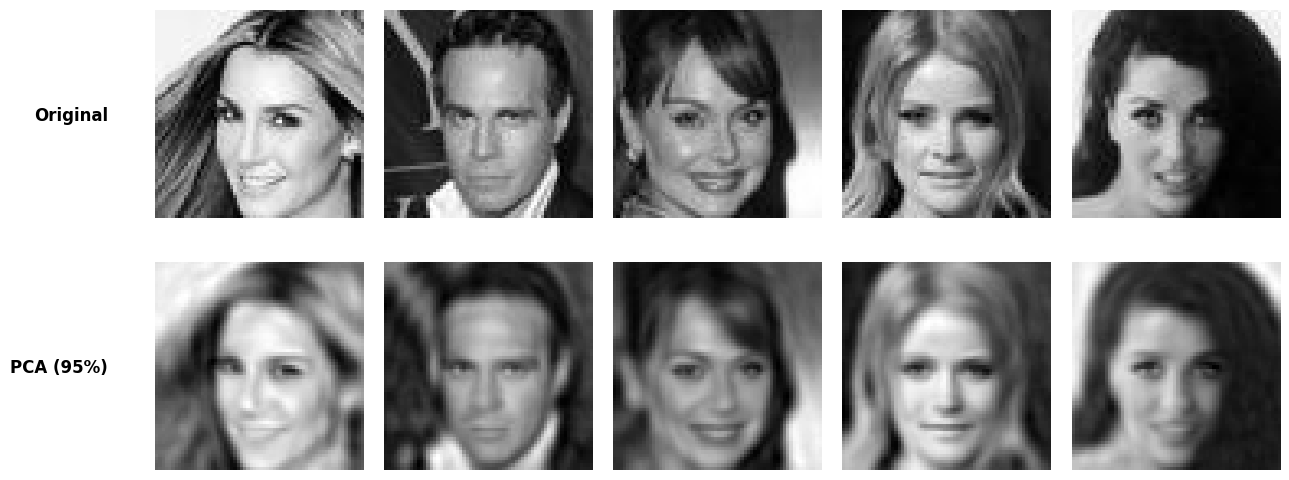

In [ ]:
# 1. Apply PCA preserving 95% of the variance
pca = PCA(n_components=0.95)
x_reduced = pca.fit_transform(x)
x_reconstructed = pca.inverse_transform(x_reduced)

print(f"Number of components kept: {pca.n_components_}")

# 2. Reconstruct and compare the first 5 images
plot_results(image_sets=[x[:5], x_reconstructed[:5]],
             titles=["Original", "PCA (95%)"],
             num_images=5)

2. Fit an autoencoder (AE) and reconstruct first 5 images. Compare to original images and
your results using PCA.


In [ ]:
# 1. Define the AE Model (Added conv layer)
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super(Autoencoder, self).__init__()

        # Encoder: Input 1x64x64
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # -> 32x32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 64x16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # -> 128x8x8
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, latent_dim)
        )

        # Decoder: Latent -> 128x8x8 -> 1x64x64
        self.decoder_input = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 64x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 32x32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 1x64x64
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder_input(z).view(-1, 128, 8, 8)
        return self.decoder(x)

In [ ]:
# 2. Hyperparameters & Data Loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(latent_dim=256).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_loader = DataLoader(ten_k_dataset, batch_size=64, shuffle=True)

In [ ]:
# 3. Training loop
epochs = 15
model.train()

for epoch in tqdm(range(epochs)):
    train_loss = 0
    for batch, _ in train_loader:
        # If your batch is [64, 64, 64] (missing channel dim), use:
        batch = batch.to(device)
        if len(batch.shape) == 3:
            batch = batch.unsqueeze(1)

        # Forward pass
        outputs = model(batch)
        loss = criterion(outputs, batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Loss: {train_loss/len(train_loader):.4f}")

  7%|▋         | 1/15 [00:05<01:18,  5.59s/it]

Loss: 0.0273


 13%|█▎        | 2/15 [00:11<01:12,  5.55s/it]

Loss: 0.0111


 20%|██        | 3/15 [00:16<01:04,  5.34s/it]

...

Loss: 0.0035


 93%|█████████▎| 14/15 [01:14<00:05,  5.33s/it]

Loss: 0.0034


100%|██████████| 15/15 [01:19<00:00,  5.32s/it]

Loss: 0.0033


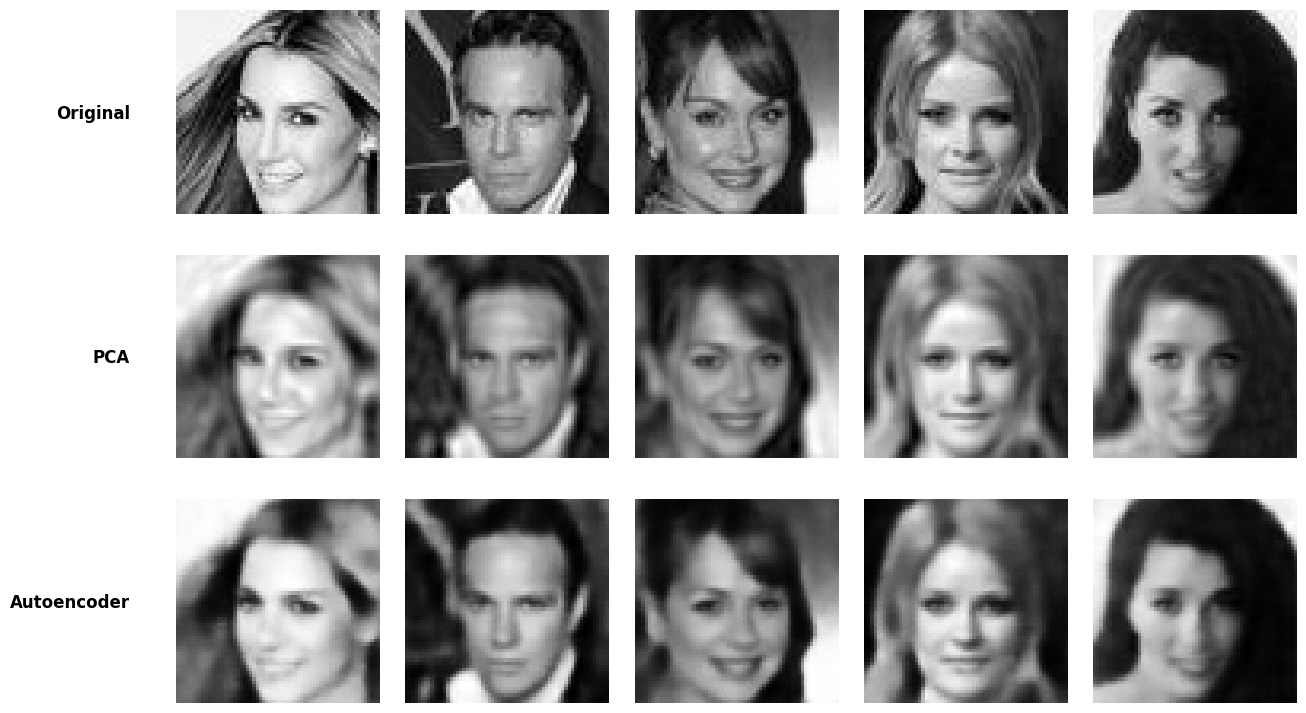

In [ ]:
# 4. Reconstruct and Compare
model.eval()
with torch.no_grad():
    # Get first 5 images from our data matrix 'x' (already normalized 0-1)
    x_tensor = torch.FloatTensor(x[:5]).view(-1, 1, 64, 64).to(device)
    ae_reconstructions_4d = model(x_tensor)
    ae_reconstructions = ae_reconstructions_4d.view(5, -1).cpu().numpy()

# Plotting
plot_results(
    image_sets=[x[:5], x_reconstructed[:5], ae_reconstructions],
    titles=["Original", "PCA", "Autoencoder"],
    num_images=5
)

3. Fit variational autoencoder (VAE). Reconstruct first 5 images and compare to original images
and your results using PCA and AE.


In [ ]:
# 1. Define the VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim=256):
        super(VAE, self).__init__()
    # Encoder: 1x64x64 -> 128x8x8
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # -> 32x32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 64x16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # -> 128x8x8
            nn.ReLU(),
            nn.Flatten()
        )

        # Latent space parameters
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder: Latent -> 128x8x8 -> 1x64x64
        self.decoder_input = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 64x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 32x32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 1x64x64
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        # Reparameterization trick: z = mu + sigma * epsilon
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder_conv(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)

        # Reshape z to fit back into convolutional layers
        x_recon = self.decoder_input(z).view(-1, 128, 8, 8)
        return self.decoder_conv(x_recon), mu, logvar


# Initialize VAE
vae_model = VAE(latent_dim=256).to(device)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

In [ ]:
# 2. Loss function and training loop
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence: 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    beta = 0.75 # Add weight on KL term
    return MSE + beta * KLD

vae_model.train()
for epoch in tqdm(range(15), desc="Training VAE"):
    total_loss = 0
    for batch, _ in train_loader:
        batch = batch.to(device)
        if len(batch.shape) == 3:
            batch = batch.unsqueeze(1)

        recon_batch, mu, logvar = vae_model(batch)
        loss = vae_loss_function(recon_batch, batch, mu, logvar)

        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Avg Loss: {total_loss/len(ten_k_dataset):.4f}")

Training VAE:   7%|▋         | 1/15 [00:06<01:31,  6.53s/it]

Epoch 1, Avg Loss: 79.3564


Training VAE:  13%|█▎        | 2/15 [00:11<01:14,  5.77s/it]

Epoch 2, Avg Loss: 77.1169


Training VAE:  20%|██        | 3/15 [00:17<01:08,  5.71s/it]

...

Epoch 13, Avg Loss: 74.5528


Training VAE:  93%|█████████▎| 14/15 [01:17<00:05,  5.49s/it]

Epoch 14, Avg Loss: 74.3699


Training VAE: 100%|██████████| 15/15 [01:22<00:00,  5.51s/it]

Epoch 15, Avg Loss: 74.2711


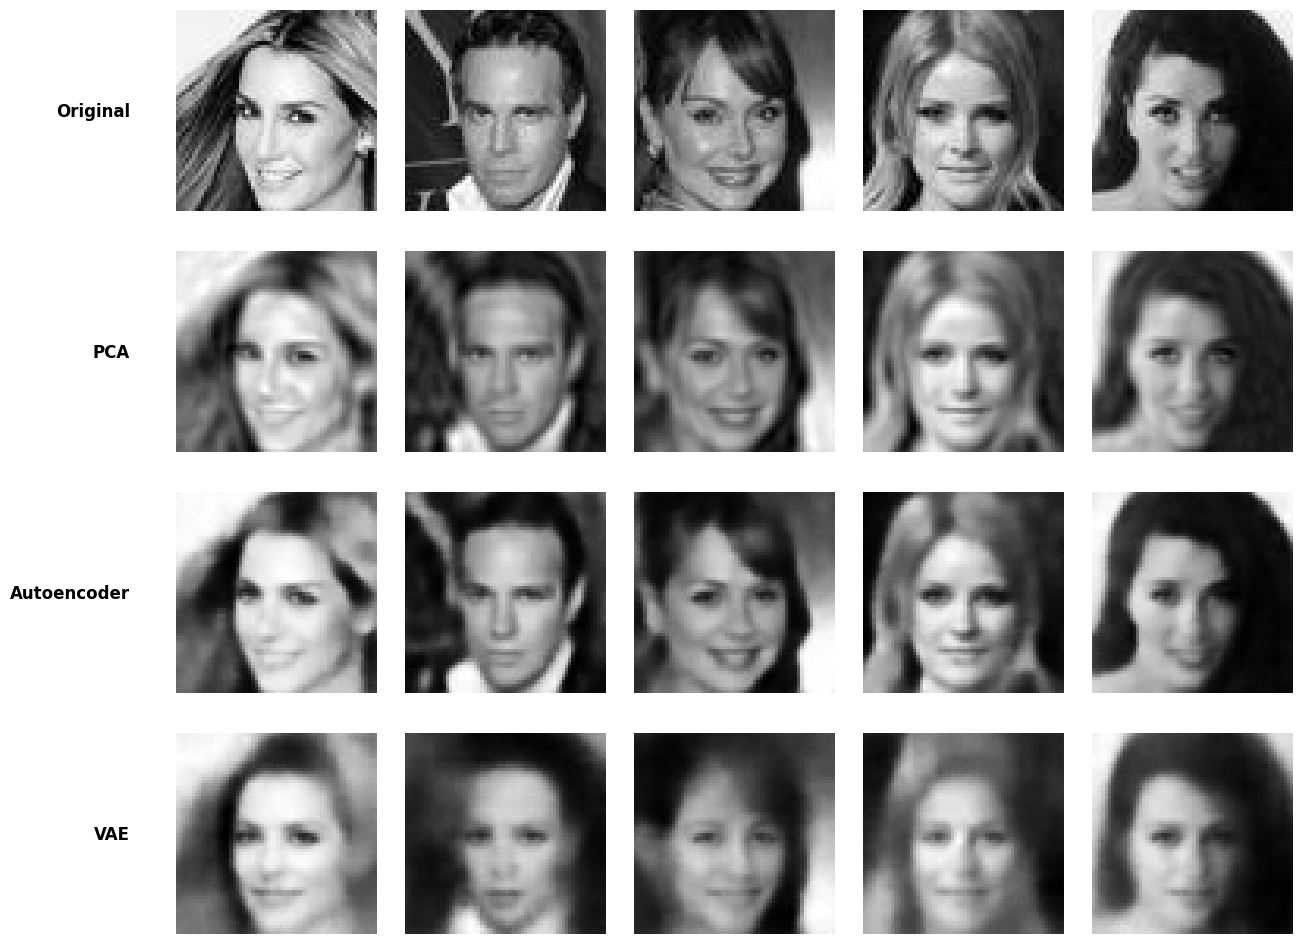

In [ ]:
# 3. Reconstruction and Compare
vae_model.eval()
with torch.no_grad():
    # Prepare the first 5 images
    x_tensor = torch.FloatTensor(x[:5]).view(-1, 1, 64, 64).to(device)
    vae_recon_4d, _, _ = vae_model(x_tensor)
    # Get VAE Reconstructions
    vae_reconstructions = vae_recon_4d.view(5, -1).cpu().numpy()

# Plotting
plot_results(
    image_sets=[x[:5], x_reconstructed[:5], ae_reconstructions, vae_reconstructions],
    titles=["Original", "PCA", "Autoencoder", "VAE"],
    num_images=5
)

4. Generate 10 images using the trained VAE and comment on the synthetic images generated.


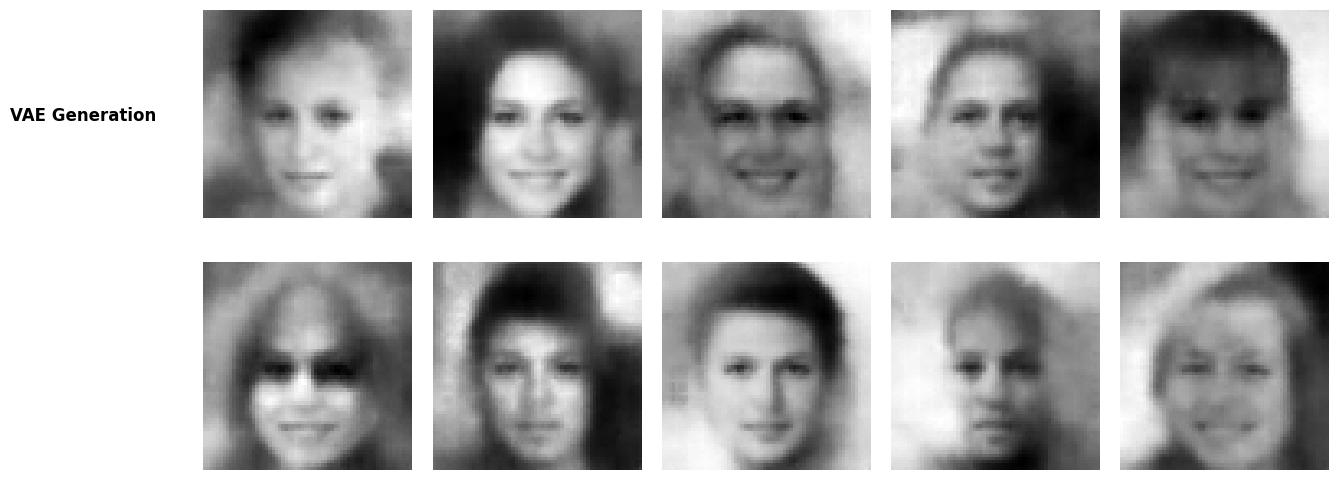

In [ ]:
vae_model.eval()
with torch.no_grad():
    # Sample 10 random vectors from a standard normal distribution
    latent_dim = 256
    z_samples = torch.randn(10, latent_dim).to(device)

    # Map latent to conv shape and decode
    z_reshaped = vae_model.decoder_input(z_samples).view(-1, 128, 8, 8)
    generated_images_4d = vae_model.decoder_conv(z_reshaped)

    # Flatten
    generated_images = generated_images_4d.view(10, -1).cpu().numpy()

# Plotting
plot_results(
    image_sets=[generated_images[:5], generated_images[5:10]],
    titles=["VAE Generation", ""],
    num_images=5
)

5. For the first 5 images, generate random noise from normal distribution with mean 0 and
standard deviation 0.5 and add it to the output of the encoder and pass it through the
decoder of the AE and reconstruct the images. Also add the same random noise to the latent
sample of the VAE for the first 5 images and pass it through the decoder of the VAE and
reconstruct the images. Which model performs better in terms of reconstructing images from
the noisy latent representation?

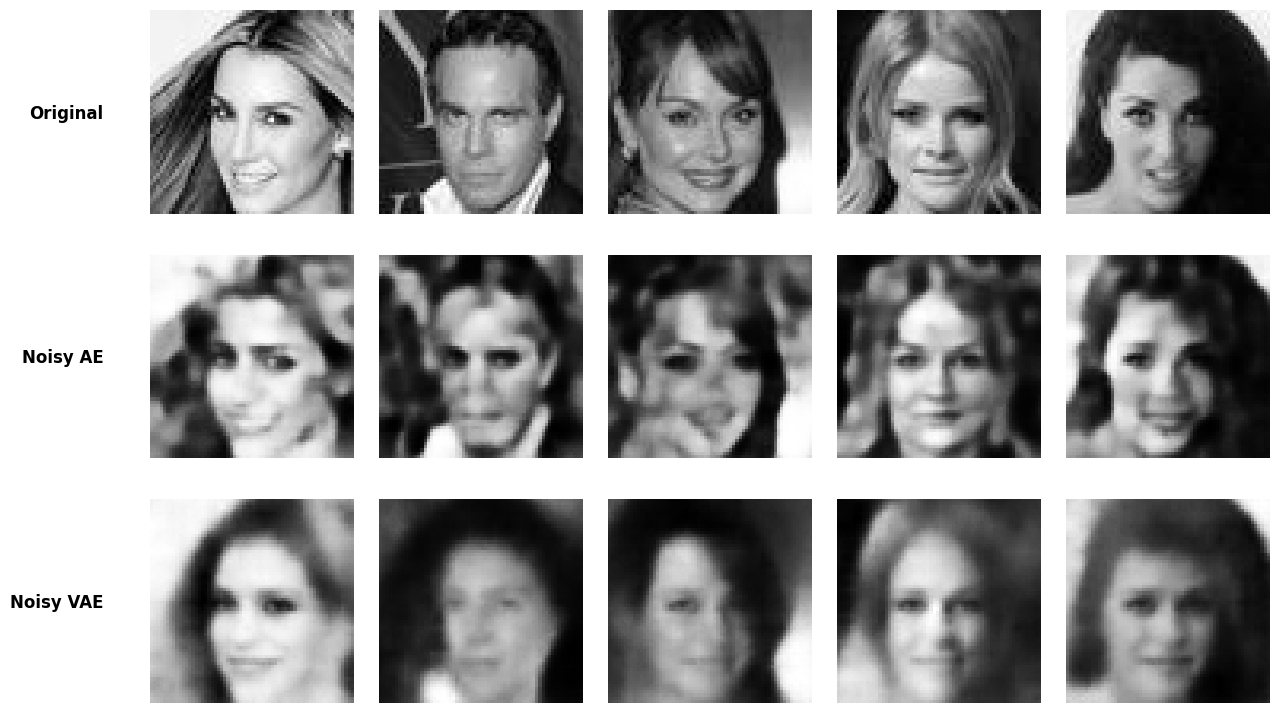

In [ ]:
# 1. Define noise parameters
noise_std = 0.5
model.eval()
vae_model.eval()

with torch.no_grad():
    # Use first 5 images
    x_tensor = torch.FloatTensor(x[:5]).view(-1, 1, 64, 64).to(device)

    # --- AE Noisy Reconstruction ---
    ae_latent = model.encoder(x_tensor)
    ae_noisy_latent = ae_latent + torch.randn_like(ae_latent) * noise_std

    # FIX: Use 'model.decoder' for AE as defined in your provided AE class
    ae_noisy_input_to_conv = model.decoder_input(ae_noisy_latent).view(-1, 128, 8, 8)
    ae_noisy_recon_4d = model.decoder(ae_noisy_input_to_conv)
    ae_noisy_recon = ae_noisy_recon_4d.view(5, -1).cpu().numpy()

    # --- VAE Noisy Reconstruction ---
    h = vae_model.encoder_conv(x_tensor)
    mu, logvar = vae_model.fc_mu(h), vae_model.fc_logvar(h)

    # Sample + Noise
    z = vae_model.reparameterize(mu, logvar)
    vae_noisy_latent = z + torch.randn_like(z) * noise_std

    # FIX: Use 'vae_model.decoder_conv' for VAE as defined in your VAE class
    vae_noisy_input_to_conv = vae_model.decoder_input(vae_noisy_latent).view(-1, 128, 8, 8)
    vae_noisy_recon_4d = vae_model.decoder_conv(vae_noisy_input_to_conv)
    vae_noisy_recon = vae_noisy_recon_4d.view(5, -1).cpu().numpy()

# 2. Plotting the Comparison
plot_results(
    image_sets=[x[:5], ae_noisy_recon, vae_noisy_recon],
    titles=["Original", "Noisy AE", "Noisy VAE"]
)

> In this case, VAE performs better under noisy conditions. Since the VAE is trained to handle variance during the reparameterization step, its decoder is "robust" to small shifts in the latent space, allowing it to maintain the overall structure of the face even when noise is added.

> The Autoencoder struggles with noisy latent representations because it maps inputs to discrete points in space, moving that point with noise often results in "ghosting" or loss of structural integrity (e.g., like nose disappearing in above images).